# OpenStreetMap

In [ ]:
import geopandas as gpd

## Carga de datos

In [ ]:
path_pbf = 'osm/andalucia-260305.osm.pbf'

# 1. Extraer el polígono de la Provincia de Cádiz (Admin Level 6)
provincia_cadiz = gpd.read_file(
    path_pbf,
    engine='pyogrio',
    layer='multipolygons',
    where="admin_level = '6' AND name = 'Cádiz'"
)

# 2. Extraer todos los municipios (Admin Level 8) de Andalucía
municipios_and = gpd.read_file(
    path_pbf,
    engine='pyogrio',
    layer='multipolygons',
    where="admin_level = '8'"
)

In [ ]:
provincia_cadiz

In [ ]:
# Es vital que ambos tengan el mismo Sistema de Referencia (CRS)
# Generalmente OSM viene en EPSG:4326
municipios_and = municipios_and.to_crs(provincia_cadiz.crs)

# Realizamos la unión espacial
# 'inner' para quedarnos solo con los que coinciden
# 'within' asegura que el municipio esté dentro de la provincia
municipios_cadiz = gpd.sjoin(municipios_and, provincia_cadiz, predicate='within', how='inner')

# Limpiar columnas duplicadas tras el join (opcional)
municipios_cadiz = municipios_cadiz[['name_left', 'geometry', 'admin_level_left']]
municipios_cadiz.columns = ['name', 'geometry', 'admin_level']

In [ ]:
lista_limites = []

for idx, row in municipios_cadiz.iterrows():
    # .bounds devuelve (minx, miny, maxx, maxy)
    minx, miny, maxx, maxy = row['geometry'].bounds
    
    lista_limites.append({
        'municipio': row['name'],
        'bbox': [minx, miny, maxx, maxy]
    })

# Ejemplo de visualización rápida
print(f"Total municipios encontrados en Cádiz: {len(municipios_cadiz)}")
print(f"Límites de {lista_limites[0]['municipio']}: {lista_limites[0]['bbox']}")

In [ ]:
lista_limites

Ya tenemos una lista con los municipios de Cádiz y su bounding box correspondiente

# Copernicus

Mi intención era, en principio, utilizar Copernicus para obtener las distintas bandas de las imágenes satelitales y poder crear el indice de vegetación de cada provincia. Para mi sorpresa la resolución de las imágenes del Sentinel (satélite de Copernicus) es de 1 pixel por cada 100 m^2 (cuadrado de 10 metros por 10 metros). Esto hace que un árbol o incluso varios árboles queden reducidos a "No vegetacion" en caso de estar rodeado de pavimento.

La única solución posible era utilizarlo y reconocer que habrá un margen de error. Pero la solución no era esa...

Gracias al [cnig](https://centrodedescargas.cnig.es/CentroDescargas/resultados-busqueda) podemos descargar imágenes satelitales con resolución de hasta 0.25 metros buscando: "Ortofotos PNOA Máxima Actualidad". Pero el proceso de descarga será más tedioso que el de Copernicus

# CNIG

No es tan sencillo como en copernicus. Aquí no puedes buscar por coordenadas, tienes que buscar por cuadrantes. Por ejemplo para el cuadrante de San Fernando (Cádiz) he tenido que descargarme un [PDF de actualización de cuadrantes](files/20240513_ACTUALIZACIÓN_MA_118_MAD.pdf) donde se puede ver que es el número 1068, el cuadrante 2. Como el buscador es una atrocidad al intelecto humano utilizamos la vieja confiable de los indexados de Google: "1068-2 site:https://centrodedescargas.cnig.es" y mágicamente nos aparece nuestro archivo de San Fernando. Lo malo es que es de 2023, pero creo que se puede compensar con la ganacia de resolución.

Parece ser que con eso no me valía, porque me estaba dando otro archivo. Hay que meterse en el [visor de mapa](https://centrodedescargas.cnig.es/CentroDescargas/buscar-mapa) y en "Buscar por punto" seleccionas el punto de San Fernando. Ahí en la parte de "Imágenes aéreas y satelitales" puedes incluso descargar las de Sentinel-2 o buscar en "Ortofotos ..."

## Imágenes necesarias

Copernicus te permitía descargar un cuadrante de la anchura y de la altura que tu quisieras. Pero con CNIG al estar divididos por cuadrantes es necesario descargarse (para el caso de uso de la pronvicia de Cádiz) aproximadamente (aún no lo se con total seguridad) 74 cuadrantes.

Los cuadrantes necesarios pueden verse en la siguiente imagen coloreados de azul.

![Imagen cuadrantes necesarios provincia de Cádiz](./files/cuadrantes-necesarios.png)

## Zona de prueba

In [1]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np

In [2]:
np.seterr(divide='ignore', invalid='ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [3]:
# https://centrodedescargas.cnig.es/CentroDescargas/detalleArchivo?sec=11369831
raw_image = rasterio.open('osm/PNOA_MA_IRG_OF_ETRS89_HU29_h25_1068_2.tif')

imagen_falso_infrarrojo = raw_image.read(
    out_shape=(raw_image.count, int(raw_image.height / 10), int(raw_image.width / 10)),
    resampling=rasterio.enums.Resampling.bilinear
)

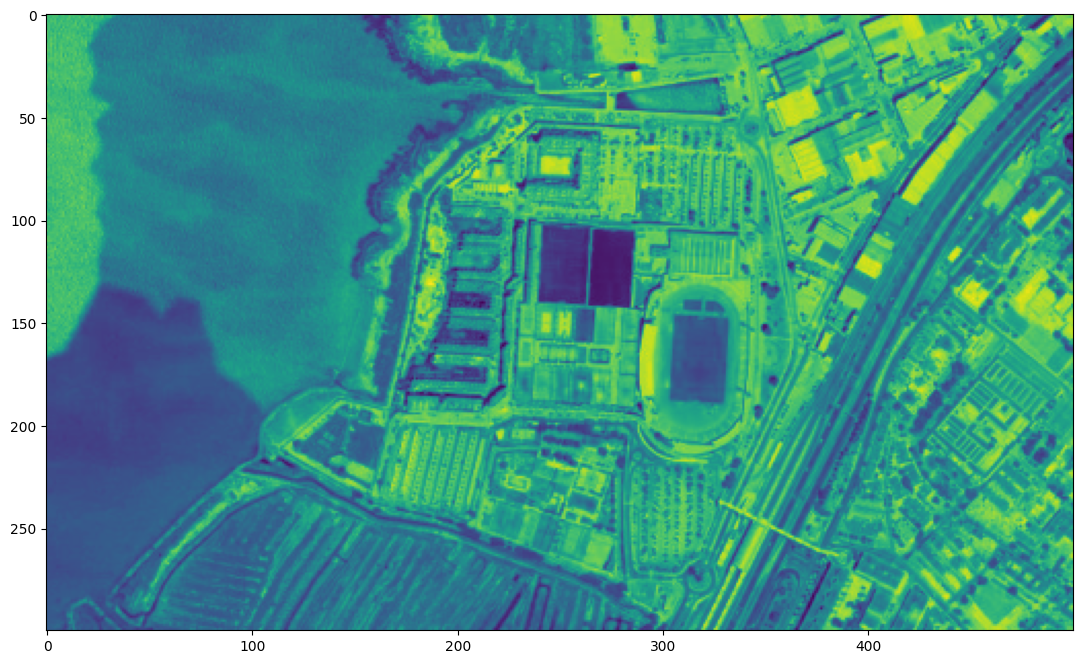

In [4]:
plt.figure(figsize=(14,8))
show(
    imagen_falso_infrarrojo[2][1200:1500, 5000:5500]
)
plt.show()

Como podemos ver aquí se puede ver mar a la izquierda, varios campos de fútbol, pero solo el de la izquierda es de césped natural, los dos mas pequeños son de cesped artificial. Así como justo a la derecha del campo de césped natural tenemos varios árboles.

Las bandas que tenemos son:

* 0: NIR

* 1: Red

* 2: Green

In [5]:
band_0 = imagen_falso_infrarrojo[0].astype('float32')
band_1 = imagen_falso_infrarrojo[1].astype('float32')
band_2 = imagen_falso_infrarrojo[2].astype('float32')

## Green NDVI

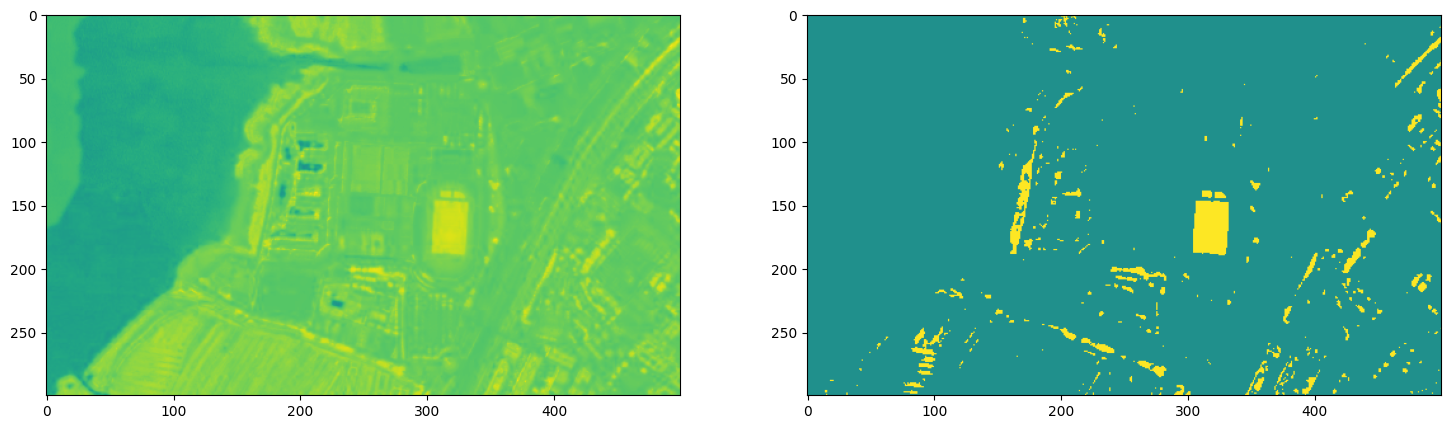

In [6]:
green_ndvi = (band_0 - band_2) / (band_0 + band_2)
green_ndvi = np.nan_to_num(green_ndvi, nan=-1)

green_ndvi_cut_o = green_ndvi[1200:1500, 5000:5500]
green_ndvi_cut   = green_ndvi_cut_o >= 0.3

plt.figure(figsize=(18,8))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)
show(
    green_ndvi_cut_o,
    # cmap='RdYlGn',
    ax=ax1,
    vmin=-1,
    vmax=1,
)
show(
    green_ndvi_cut,
    ax=ax2,
    vmin=-1,
    vmax=1,
)
plt.show()

Como podemos ver en la imagen de la izquierda solamente el campo de césped natural aparece marcado por el índice GreenNDVI. Además de los árboles que se encuentran a su lado derecho en la imagen.

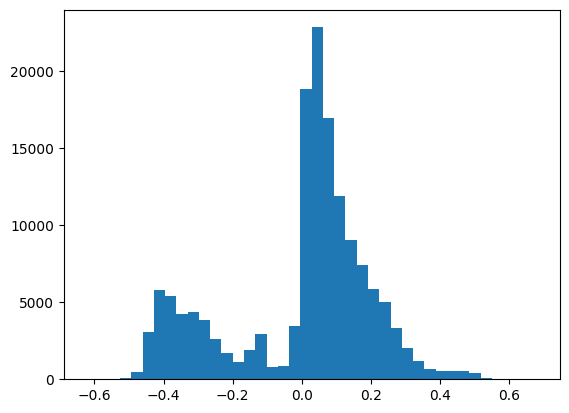

In [12]:
plt.hist(
    np.hstack(green_ndvi_cut_o),
    bins=40
)
plt.show()

## NVDI

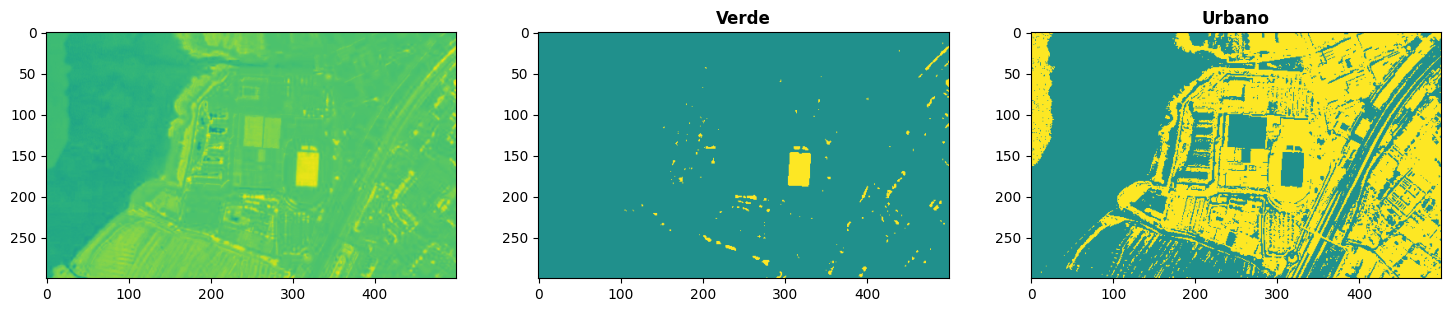

In [8]:
brillo = (band_0 + band_1 + band_2) / (3.0)
brillo_cut = brillo[1200:1500, 5000:5500]

ndvi = (band_0 - band_1) / (band_0 + band_1)
ndvi = np.nan_to_num(ndvi, nan=-1)

ndvi_cut_o = ndvi[1200:1500, 5000:5500]
ndvi_cut   = (ndvi_cut_o >= 0.4)

plt.figure(figsize=(18,8))
ax1 = plt.subplot(1, 3, 1)
ax2 = plt.subplot(1, 3, 2)
ax3 = plt.subplot(1, 3, 3)
show(
    ndvi_cut_o,
    # cmap='RdYlGn',
    ax=ax1,
    vmin=-1,
    vmax=1,
)
show(
    ndvi_cut,
    ax=ax2,
    vmin=-1,
    vmax=1,
    title='Verde'
)
show(
    (ndvi_cut < 0.1) & (ndvi_cut > -0.1) & (brillo_cut > 150),
    ax=ax3,
    vmin=-1,
    vmax=1,
    title='Urbano'
)
plt.show()

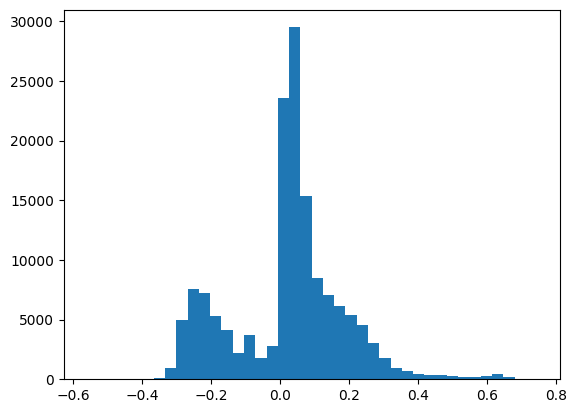

In [13]:
plt.hist(
    np.hstack(ndvi_cut_o),
    bins=40
)
plt.show()